In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load sample churn dataset
df = pd.read_csv('D:\\Phani\\etechguild\\syllabus\\demo\\lessons\\python\\EDA\\WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Convert Incorrect Data Types
# Convert TotalCharges to numeric (some values may be blank)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')


In [4]:
#Remove Values Beyond Logical Range
# Remove negative tenure or extremely high values
df = df[(df['tenure'] >= 0) & (df['tenure'] <= 100)]


In [5]:
# Remove Values Not in a Valid List
# Validate Contract types
valid_contracts = ['Month-to-month', 'One year', 'Two year']
df = df[df['Contract'].isin(valid_contracts)]


In [6]:
#Correct Wrong Structure
# Remove rows with missing customerID
df = df[df['customerID'].notnull()]


In [7]:
#Validate Internal Rules
# Ensure MonthlyCharges and TotalCharges are positive
df = df[(df['MonthlyCharges'] > 0) & (df['TotalCharges'] > 0)]


## Filtering Data

In [8]:
df.drop_duplicates(subset='customerID', inplace=True)


In [9]:
# Filter customers with fiber optic internet
df_fiber = df[df['InternetService'] == 'Fiber optic']

# Filter customers who churned
df_churned = df[df['Churn'] == 'Yes']


In [10]:
# Filter Columns for Analysis
df_filtered = df[['customerID', 'Churn', 'Contract', 'tenure', 'MonthlyCharges', 'TotalCharges']]


In [11]:
# Aggregate Data
# Churn rate by contract type
churn_rate = df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean()).reset_index(name='ChurnRate')
print(churn_rate)


         Contract  ChurnRate
0  Month-to-month   0.427097
1        One year   0.112772
2        Two year   0.028487


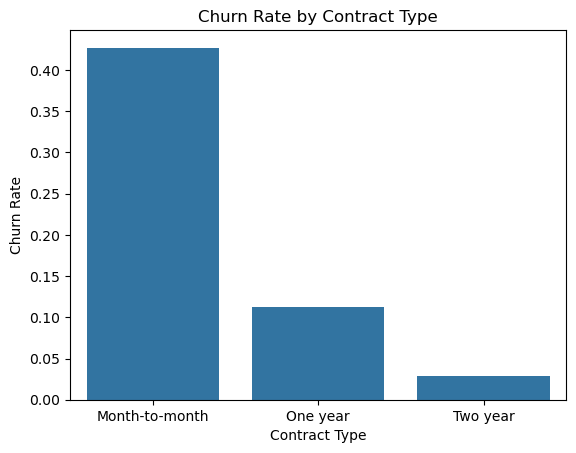

In [12]:
# Visual Check
sns.barplot(x='Contract', y='ChurnRate', data=churn_rate)
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate")
plt.xlabel("Contract Type")
plt.show()
